<a href="https://colab.research.google.com/github/rakshunaga007-hub/CODSOFT/blob/main/image_captioning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cpu


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

Model loaded successfully!

Upload an image...


Saving icnsFile_e33aa3a9a21272628ebc9151096686ac_YouTube__Liquid_Glass_.icns to icnsFile_e33aa3a9a21272628ebc9151096686ac_YouTube__Liquid_Glass_.icns


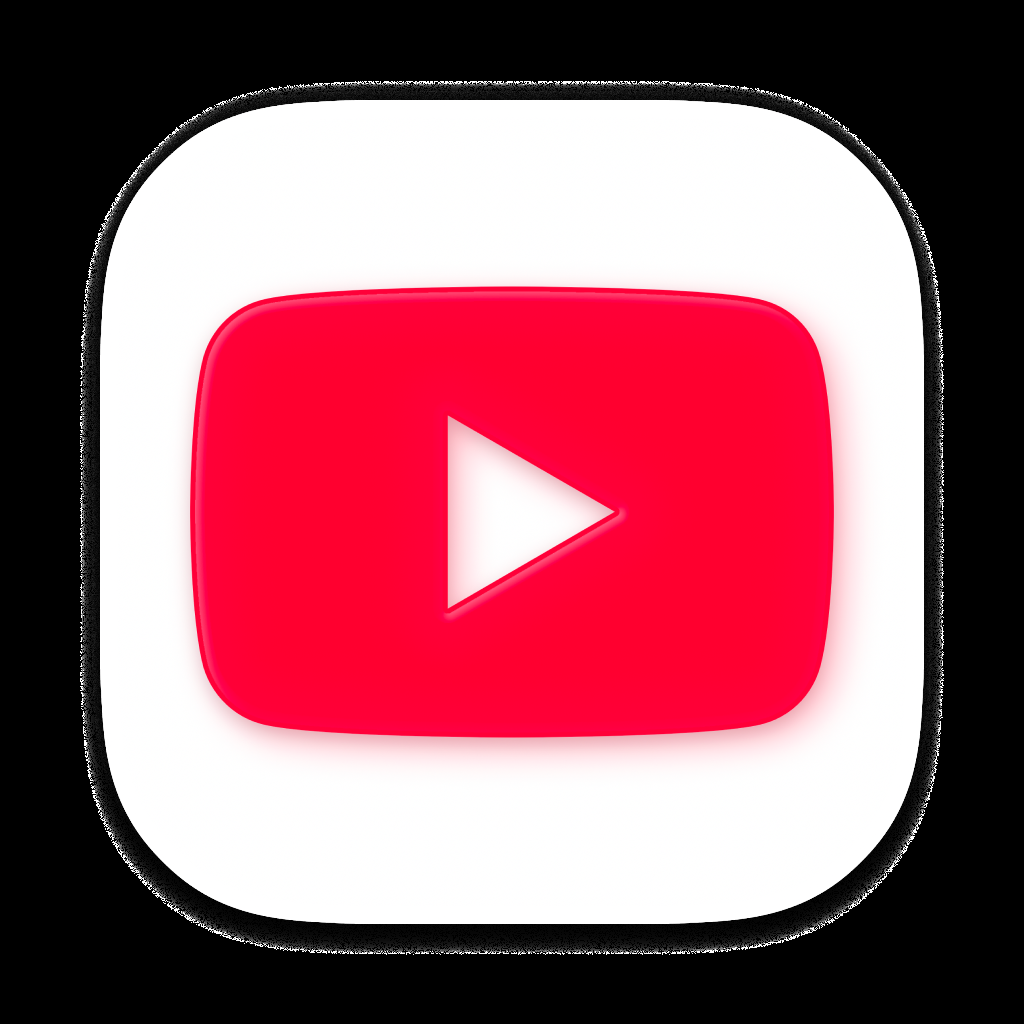


Generated Caption:
a red youtube icon on a white background


In [ ]:
 !pip -q install transformers torch torchvision pillow accelerate

from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
from google.colab import files
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)

model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(device)

print("Model loaded successfully!")

print("\nUpload an image...")
uploaded = files.upload()

image_path = list(uploaded.keys())[0]

image = Image.open(image_path).convert("RGB")

display(image)

inputs = processor(
    images=image,
    return_tensors="pt"
).to(device)

with torch.no_grad():
    output = model.generate(
        **inputs,
        max_length=50,
        num_beams=5
    )

caption = processor.decode(
    output[0],
    skip_special_tokens=True
)

print("\nGenerated Caption:")
print(caption)